In [1]:
from functools import partial

import equinox as eqx
import jax
import jax.numpy as jnp
import colorcet as cc
import matplotlib
import matplotlib.pyplot as plt
import scipy.spatial as scspatial
import diffrax as dfx
from jaxtyping import Int, Float, Array

from dynamical_systems.continuous import Lorenz63
from dynamical_systems.dataset import TimeSeriesDataset
from dynamics_discovery.preprocessing import standardize
from dynamics_discovery.models import LatentLSTM

jax.config.update("jax_enable_x64", True)
plt.style.use("matplotlib_utils.styles.dash_gridded")

In [2]:
dataset_loaded = TimeSeriesDataset.load("./data/lorenz63.hdf5")[30000:]
t_train = dataset_loaded.t[0]
u_orig = dataset_loaded.u[0]
u_train = standardize(u_orig)
u_std = jnp.std(u_orig, axis=0)

lorenz = Lorenz63()

## Calculate the ground truth one step jacobian of the ODE system


In [3]:
def step(ode, t0, t1, u0):
    sol = dfx.diffeqsolve(
        dfx.ODETerm(ode.rhs),
        dfx.Tsit5(),
        t0,
        t1,
        None,
        u0,
        stepsize_controller=dfx.PIDController(rtol=1e-7, atol=1e-7),
        args=None,
    )
    return sol.ys[0]


@partial(eqx.filter_vmap, in_axes=(None, 0, 0, None))
def jacobian_one_step(ode, t, u, dt):
    @eqx.filter_jacrev
    def _jac_step(t_u):
        t, u = t_u
        return step(ode, t, t + dt, u)

    return _jac_step((t, u))[1]

In [4]:
u_orig.shape

(100000, 3)

In [5]:
jac_unscaled = jacobian_one_step(lorenz, t_train, u_orig, t_train[1] - t_train[0])
jac_unscaled.shape
jac_true = jnp.diag(1 / u_std) @ jac_unscaled @ jnp.diag(u_std)
jac_true.shape

(100000, 3, 3)

In [6]:
kdtree = scspatial.KDTree(u_train[:-1])

num_neighbors = 10
_, idx_nn_ = kdtree.query(u_train[:-1], k=num_neighbors + 1)
idx_nn = idx_nn_[:, 1:]

In [7]:
idx_nn.shape

(99999, 10)

In [8]:
example_ind = 30


@partial(eqx.filter_vmap, in_axes=(None, 0, 0))
def estimate_jacobian(us: Float[Array, "time dim"], idx, idx_nn):
    u0, u1 = us[idx], us[idx + 1]
    u_nn0 = jnp.take(us, idx_nn, axis=0)
    u_nn1 = jnp.take(us, idx_nn + 1, axis=0)

    du0 = u_nn0 - u0
    du1 = u_nn1 - u1
    return (jnp.linalg.pinv(du0) @ du1).T


jac_linregress = estimate_jacobian(u_train, jnp.arange(u_train.shape[0] - 1), idx_nn)


In [9]:
def relative_error(
    y_pred: Float[Array, "batch *rest"],
    y_true: Float[Array, "batch *rest"],
    axis: int = -1,
    ord: int | None = None,
):
    norm_true = jnp.linalg.norm(y_true, ord=ord, axis=axis)
    norm_err = jnp.linalg.norm(y_pred - y_true, ord=ord, axis=axis)
    return norm_err / norm_true


err_linregress = relative_error(jac_linregress, jac_true[:-1], axis=(-2, -1))

(array([7.5045e+04, 1.5815e+04, 4.9170e+03, 2.2880e+03, 1.0650e+03,
        4.9500e+02, 2.2600e+02, 9.1000e+01, 2.8000e+01, 1.2000e+01,
        3.0000e+00, 2.0000e+00, 2.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

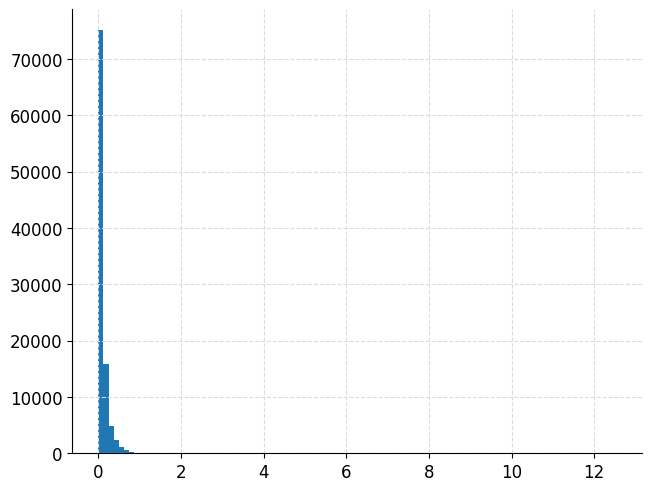

In [10]:
plt.hist(err_linregress, bins=100)

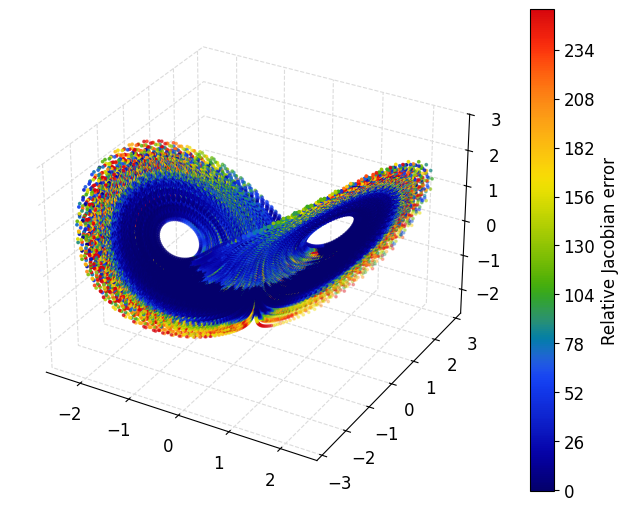

In [55]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(7, 5),
    subplot_kw={"projection": "3d"},
)
clip_percentile = 1
colors = jnp.clip(
    err_linregress,
    min=jnp.percentile(err_linregress, clip_percentile),
    max=jnp.percentile(err_linregress, 100 - clip_percentile),
)
ax.scatter(
    *u_train[:-1].T,
    c=colors,
    s=3,
    cmap=cc.cm.rainbow4,
)
fig.colorbar(
    matplotlib.cm.ScalarMappable(
        cmap=cc.cm.rainbow4,
        norm=matplotlib.colors.NoNorm(),
    ),
    ax=[ax],
    label=r"Relative Jacobian error",
)

## Jacobian estimation via neural network

In [94]:
from functools import partial


def estimate_step_error(
    model,
    t0: Float[Array, ""],
    u0: Float[Array, " dim"],
    du0: Float[Array, "samples dim"],
    dt: Float[Array, ""],
):
    def _step(u):
        return model.step(t0, t0 + dt, u)

    @partial(eqx.filter_vmap, in_axes=(None, 0))
    def _step_error(u, du):
        return eqx.filter_jvp(_step, (u,), (du,))[1]

    return _step_error(u0, du0)


@partial(eqx.filter_vmap, in_axes=(None, None, None, 0, 0, None))
def loss_step_error(model, ts, us, idx, idx_nn, dt):
    t0, u0 = ts[idx], us[idx]
    dt = ts[1] - ts[0]
    du0 = jnp.take(us, idx_nn, axis=0) - u0
    du1 = jnp.take(us, idx_nn + 1, axis=0) - us[idx + 1]
    du1_pred = estimate_step_error(model, t0, u0, du0, dt)
    return jnp.mean((du1 - du1_pred) ** 2) / jnp.mean((du1) ** 2)


@partial(eqx.filter_vmap, in_axes=(None, 0, 0, 0, None))
def loss_temporal(model, t0, u0, u1, dt):
    u1_pred = model.step(t0, t0 + dt, u0)
    return jnp.mean((u1_pred - u1) ** 2) / jnp.mean((u1) ** 2)


@eqx.filter_value_and_grad
def loss_grad_fn(model, t_train, u_train, idx_nn):
    dt = t_train[1] - t_train[0]
    loss_step = jnp.mean(
        loss_step_error(
            model, t_train, u_train, jnp.arange(u_train.shape[0] - 1), idx_nn, dt
        )
    )
    return loss_step


@eqx.filter_value_and_grad
def hybrid_loss_grad_fn(model, t_train, u_train, idx_nn):
    dt = t_train[1] - t_train[0]
    loss_step = jnp.mean(
        loss_step_error(
            model, t_train, u_train, jnp.arange(u_train.shape[0] - 1), idx_nn, dt
        )
    )
    loss_time = jnp.mean(
        loss_temporal(model, t_train[:-1], u_train[:-1], u_train[1:], dt)
    )
    return loss_step + loss_time

In [72]:
import optax

model = LatentLSTM(3, 30, key=0)
optimizer = optax.adabelief(learning_rate=2e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def step_fn(model, t_train, u_train, idx_nn, opt_state):
    loss, grads = loss_grad_fn(model, t_train, u_train, idx_nn)
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


In [73]:
loss_history = []
max_epochs = 5000
for epoch in range(max_epochs):
    loss, model, opt_state = step_fn(model, t_train, u_train, idx_nn, opt_state)
    loss_history.append(loss.item())
    print(f"{epoch=}, {loss=}")
loss_history = jnp.asarray(loss_history)

epoch=0, loss=Array(1.00663183, dtype=float64)
epoch=1, loss=Array(0.98436526, dtype=float64)
epoch=2, loss=Array(0.96136018, dtype=float64)
epoch=3, loss=Array(0.93771551, dtype=float64)
epoch=4, loss=Array(0.91351649, dtype=float64)
epoch=5, loss=Array(0.88886503, dtype=float64)
epoch=6, loss=Array(0.86390326, dtype=float64)
epoch=7, loss=Array(0.83881806, dtype=float64)
epoch=8, loss=Array(0.81382371, dtype=float64)
epoch=9, loss=Array(0.78912906, dtype=float64)
epoch=10, loss=Array(0.76490106, dtype=float64)
epoch=11, loss=Array(0.74124476, dtype=float64)
epoch=12, loss=Array(0.71820708, dtype=float64)
epoch=13, loss=Array(0.69579114, dtype=float64)
epoch=14, loss=Array(0.67397096, dtype=float64)
epoch=15, loss=Array(0.65270346, dtype=float64)
epoch=16, loss=Array(0.6319369, dtype=float64)
epoch=17, loss=Array(0.61161709, dtype=float64)
epoch=18, loss=Array(0.5916934, dtype=float64)
epoch=19, loss=Array(0.57212451, dtype=float64)
epoch=20, loss=Array(0.552882, dtype=float64)
epoch=

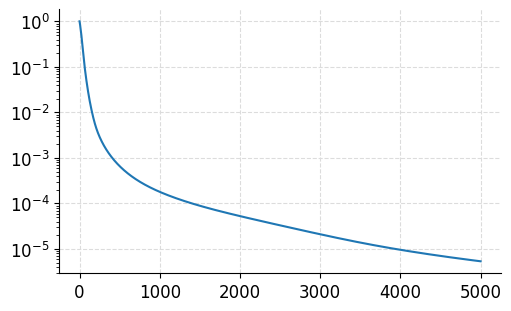

In [74]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log", base=10)

In [75]:
@partial(eqx.filter_vmap, in_axes=(None, 0, 0, None))
def jacobian_one_step_model(model, t, u, dt):
    @eqx.filter_jacrev
    def _jac_step(t_u):
        t, u = t_u
        return model.step(t, t + dt, u)

    return _jac_step((t, u))[1]

In [ ]:
jac_nn = jacobian_one_step_model(model, t_train, u_train, t_train[1] - t_train[0])
err_nn = relative_error(jac_nn, jac_true, axis=(-2, -1))

In [84]:
from dynamics_discovery.io import load_model

model_loaded = load_model("results/lorenz63/latent_lstm/len=2_noise=0.0_key=0.eqx")

jac_nn_1step = jacobian_one_step_model(
    model_loaded, t_train, u_train, t_train[1] - t_train[0]
)
err_nn_1step = relative_error(jac_nn_1step, jac_true, axis=(-2, -1))

Text(0.5, 0.98, 'Relative jacobian error')

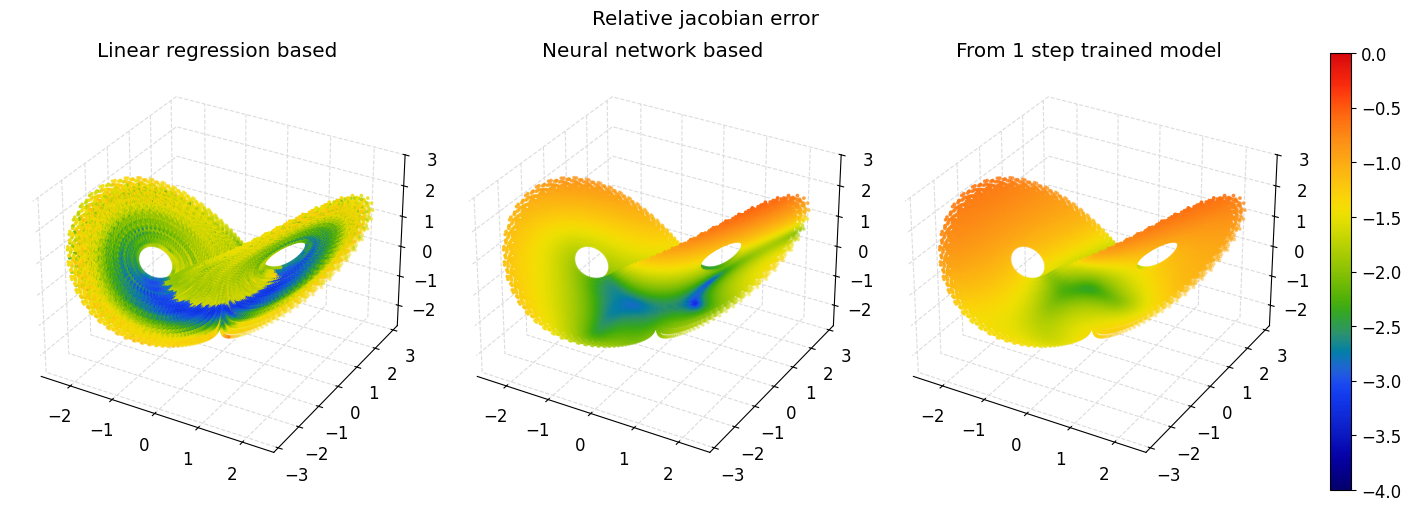

In [85]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5),
    subplot_kw={"projection": "3d"},
)

axes[0].scatter(
    *u_train[1:].T,
    c=jnp.log10(err_linregress),
    s=3,
    cmap=cc.cm.rainbow4,
    vmin=-5,
    vmax=2,
)
axes[1].scatter(
    *u_train.T, c=jnp.log10(err_nn), s=3, cmap=cc.cm.rainbow4, vmin=-4, vmax=0.0
)
ax = axes[2].scatter(
    *u_train.T, c=jnp.log10(err_nn_1step), s=3, cmap=cc.cm.rainbow4, vmin=-4, vmax=0.0
)
axes[0].set_title("Linear regression based")
axes[1].set_title("Neural network based")
axes[2].set_title("From 1 step trained model")
fig.colorbar(ax, ax=axes[-1])
fig.suptitle("Relative jacobian error")

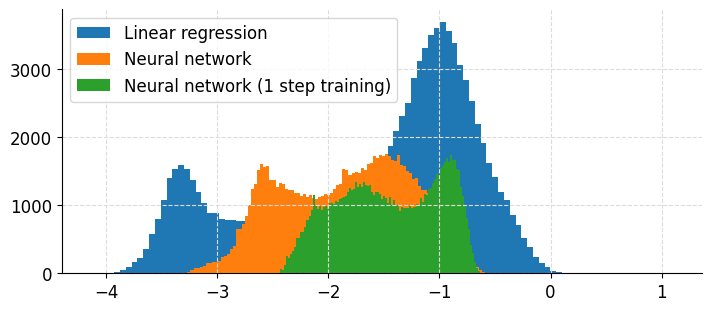

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.hist(jnp.log10(err_linregress), bins=100, label="Linear regression")
ax.hist(jnp.log10(err_nn), bins=100, label="Neural network")
ax.hist(jnp.log10(err_nn_1step), bins=100, label="Neural network (1 step training)")
ax.legend()

In [118]:
import optax

model = LatentLSTM(3, 30, key=0)
optimizer = optax.adabelief(learning_rate=2e-4)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def hybrid_step_fn(model, t_train, u_train, idx_nn, opt_state):
    loss, grads = hybrid_loss_grad_fn(model, t_train, u_train, idx_nn)
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


In [119]:
loss_history = []
max_epochs = 20000
for epoch in range(max_epochs):
    loss, model, opt_state = hybrid_step_fn(model, t_train, u_train, idx_nn, opt_state)
    loss_history.append(loss.item())
    print(f"{epoch=}, {loss=}")
loss_history = jnp.asarray(loss_history)

epoch=0, loss=Array(2.01699215, dtype=float64)
epoch=1, loss=Array(2.01233105, dtype=float64)
epoch=2, loss=Array(2.00743824, dtype=float64)
epoch=3, loss=Array(2.00231209, dtype=float64)
epoch=4, loss=Array(1.99695179, dtype=float64)
epoch=5, loss=Array(1.99135727, dtype=float64)
epoch=6, loss=Array(1.98552909, dtype=float64)
epoch=7, loss=Array(1.97946838, dtype=float64)
epoch=8, loss=Array(1.97317695, dtype=float64)
epoch=9, loss=Array(1.96665718, dtype=float64)
epoch=10, loss=Array(1.95991203, dtype=float64)
epoch=11, loss=Array(1.95294493, dtype=float64)
epoch=12, loss=Array(1.9457597, dtype=float64)
epoch=13, loss=Array(1.93836051, dtype=float64)
epoch=14, loss=Array(1.93075173, dtype=float64)
epoch=15, loss=Array(1.92293792, dtype=float64)
epoch=16, loss=Array(1.91492372, dtype=float64)
epoch=17, loss=Array(1.90671378, dtype=float64)
epoch=18, loss=Array(1.8983127, dtype=float64)
epoch=19, loss=Array(1.889725, dtype=float64)
epoch=20, loss=Array(1.88095506, dtype=float64)
epoch=

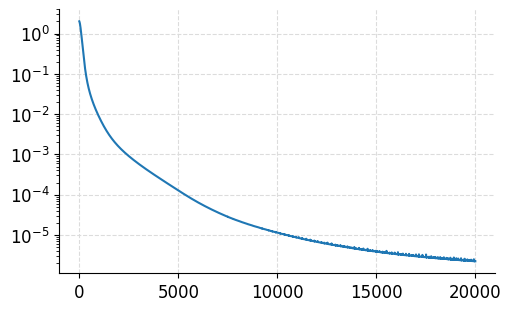

In [120]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(loss_history)
ax.set_yscale("log", base=10)

In [121]:
jac_nn = jacobian_one_step_model(model, t_train, u_train, t_train[1] - t_train[0])
err_nn = relative_error(jac_nn, jac_true, axis=(-2, -1))

Text(0.5, 0.98, 'Relative jacobian error')

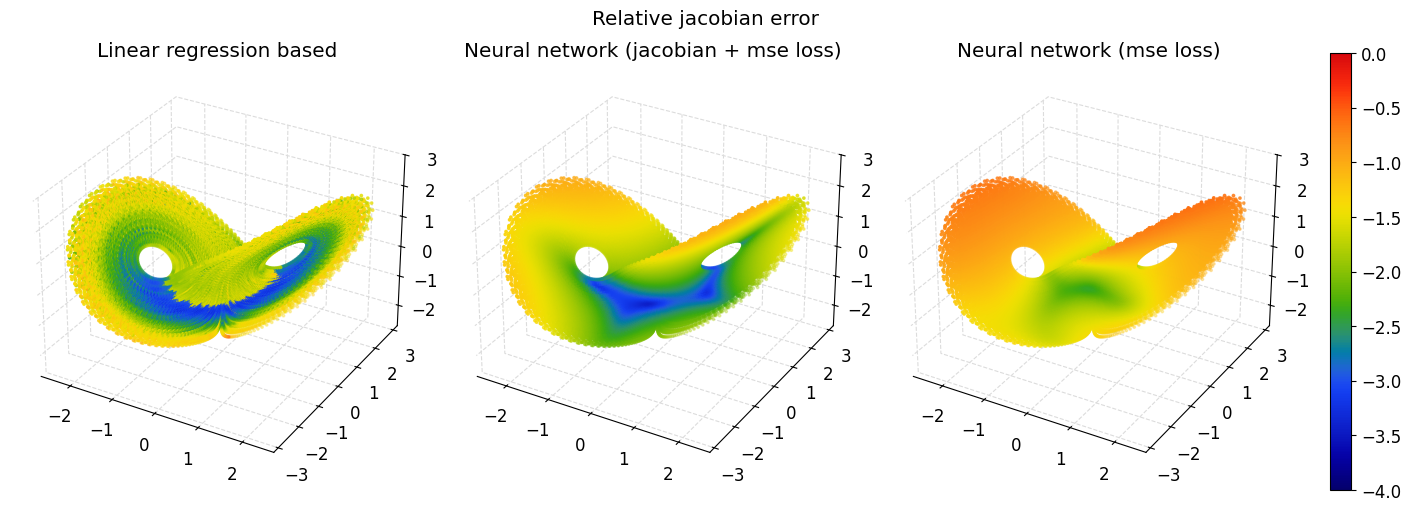

In [122]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5),
    subplot_kw={"projection": "3d"},
)

axes[0].scatter(
    *u_train[1:].T,
    c=jnp.log10(err_linregress),
    s=3,
    cmap=cc.cm.rainbow4,
    vmin=-5,
    vmax=2,
)
axes[1].scatter(
    *u_train.T, c=jnp.log10(err_nn), s=3, cmap=cc.cm.rainbow4, vmin=-4, vmax=0.0
)
ax = axes[2].scatter(
    *u_train.T, c=jnp.log10(err_nn_1step), s=3, cmap=cc.cm.rainbow4, vmin=-4, vmax=0.0
)
axes[0].set_title("Linear regression based")
axes[1].set_title("Neural network (jacobian + mse loss)")
axes[2].set_title("Neural network (mse loss)")
fig.colorbar(ax, ax=axes[-1])
fig.suptitle("Relative jacobian error")

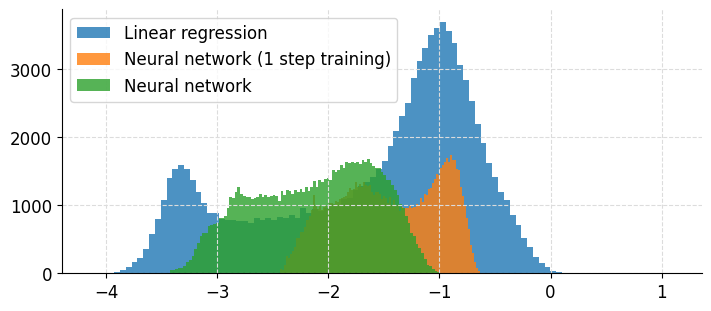

In [123]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.hist(jnp.log10(err_linregress), bins=100, label="Linear regression", alpha=0.8)
ax.hist(
    jnp.log10(err_nn_1step),
    bins=100,
    label="Neural network (1 step training)",
    alpha=0.8,
)
ax.hist(jnp.log10(err_nn), bins=100, label="Neural network", alpha=0.8)
ax.legend()

In [124]:
from dynamics_discovery.preprocessing import split_into_chunks

train_length = 2
noise = 0

t_train_batch = split_into_chunks(t_train, train_length)
u_train_batch = split_into_chunks(u_train, train_length)
# u_train_batch = add_noise(u_train_batch, noise, key=0)

subsample_factor = u_train_batch.shape[0] // 100
print(t_train_batch.shape)
u_pred_train = eqx.filter_vmap(model.solve)(
    t_train_batch[::subsample_factor], u_train_batch[::subsample_factor, 0]
)
u_pred_test = model.solve(t_train, u_train[0], max_steps=None)


(50000, 2)


Text(0.5, 0.98, 'Latent LSTM prediction (train length = 2, seed = 0)')

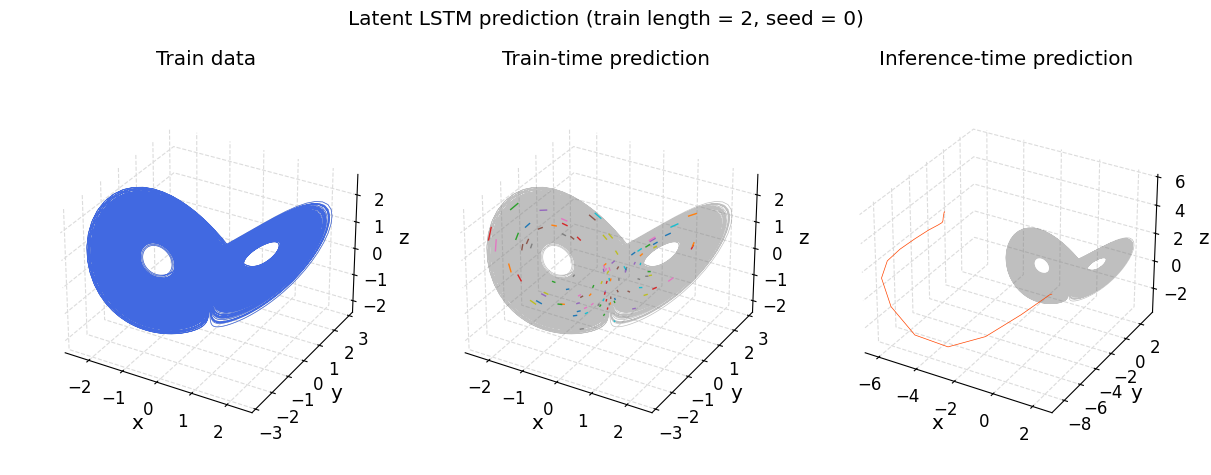

In [125]:
import numpy as np
from matplotlib_utils.axes_setters import set_labels

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 5),
    constrained_layout=True,
    subplot_kw={"projection": "3d"},
)
plot_kwargs = {"linewidth": 0.5}
axes[0].set_title("Train data")
axes[0].plot(*u_train.T, color="gray", alpha=0.5, **plot_kwargs)
axes[0].plot(*u_train.T, color="royalblue", **plot_kwargs)

axes[1].plot(*u_train.T, color="gray", alpha=0.5, **plot_kwargs)
for u_i in np.asarray(u_pred_train)[::]:
    axes[1].plot(*u_i.T, linewidth=1.0)
axes[1].set_title("Train-time prediction")
axes[2].plot(*u_train.T, color="gray", alpha=0.5, **plot_kwargs)
axes[2].plot(*u_pred_test.T, color="orangered", **plot_kwargs)
axes[2].set_title("Inference-time prediction")

for ax in axes:
    set_labels(ax, ["x", "y", "z"], fontsize="large")
    ax.set_box_aspect(None, zoom=0.85)
    ax.set_title
fig.suptitle(f"Latent LSTM prediction (train length = {train_length}, seed = 0)")
